# Synthetic 80 m → real 30 m Orthogonal Procrustes pilot

This notebook performs a small, controlled pilot of the feature-correction hypothesis using **10 matched image pairs per class**:

- boat: 10 pairs;
- buoy: 10 pairs;
- jet ski: 10 pairs;
- swimmer: 10 pairs.

For every selected object, the same frozen DINOv2 encoder extracts features from:

1. the real 30 m fixed-canvas observation;
2. its geometry-only synthetic 80 m counterpart;
3. its calibrated synthetic 80 m counterpart.

Two strict Orthogonal Procrustes matrices are fitted:

\[
R_{\mathrm{geom}}=\arg\min_{R^TR=I}\|X_{80,\mathrm{geom}}R-X_{30}\|_F^2,
\]

\[
R_{\mathrm{cal}}=\arg\min_{R^TR=I}\|X_{80,\mathrm{cal}}R-X_{30}\|_F^2.
\]

The fitted matrices are then applied to an untouched synthetic test split before its features are passed to a fixed classifier trained only on real 30 m features.

## Experimental arms

```text
Real 30 m test patch ───────── frozen encoder ───────────────► fixed 30 m probe

Geometry-only synthetic 80 m ─ frozen encoder ───────────────► fixed 30 m probe
Geometry-only synthetic 80 m ─ frozen encoder ─ R_geom ─────► fixed 30 m probe

Calibrated synthetic 80 m ───── frozen encoder ───────────────► fixed 30 m probe
Calibrated synthetic 80 m ───── frozen encoder ─ R_cal ──────► fixed 30 m probe
```

The two uncorrected arms are the actual **zero-shot baselines**. “Geometry-only” is a simulation type, not itself a definition of zero-shot.

The frozen encoder is never trained. The classifier is also fixed before any synthetic test features are evaluated.

## Important limitation of a 40-pair pilot

DINOv2-small produces 384-dimensional features. Forty uncentred pairs constrain at most 40 feature directions. Therefore, a full 384×384 orthogonal matrix is mathematically underdetermined in most directions.

This notebook still calculates the strict matrix because that is the proposed hypothesis, but treats the result as an **exploratory pilot**. Strong evidence will require more independent calibration objects, a calibration-size stability analysis, or a lower-dimensional representation fitted without test leakage.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import random
import sys
import warnings
from dataclasses import dataclass


def find_repo_root(start=Path.cwd()):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


REPO_ROOT = find_repo_root()
os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".cache" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore", message="IProgress not found.*")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModel

SEED = 42
PAIRS_PER_CLASS = 10
MODEL_NAME = "facebook/dinov2-small"
BATCH_SIZE = 32
NUM_WORKERS = 0

PAIR_MANIFEST = REPO_ROOT / "data" / "synthetic" / "seadronessee_30m_to_80m" / "manifests" / "paired_manifest.csv"
REAL30_FEATURE_ROOT = REPO_ROOT / "data" / "features" / "seadronessee" / "dinov2_small_30m"
SYNTHETIC_FEATURE_ROOT = REPO_ROOT / "data" / "features" / "seadronessee" / "dinov2_small_synthetic80_procrustes_40"
BASELINE_PROBE_PATH = REPO_ROOT / "results" / "seadronessee_30m" / "linear_probe_30m.joblib"
RESULT_ROOT = REPO_ROOT / "results" / "seadronessee_synthetic80_procrustes_40"

SYNTHETIC_FEATURE_ROOT.mkdir(parents=True, exist_ok=True)
RESULT_ROOT.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Repository:", REPO_ROOT)
print("Device:", DEVICE)
print("Result directory:", RESULT_ROOT)

Repository: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment
Device: cpu
Result directory: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_synthetic80_procrustes_40


## 1. Select 40 mapping-calibration pairs

Selection uses unique source images and cycles across available source videos to improve diversity. The final synthetic test split remains untouched.

The generated training split contains only nine eligible jet-ski objects. Consequently, the jet-ski calibration group uses all nine training objects plus one validation object. No test object is used to estimate either matrix.

In [2]:
pairs = pd.read_csv(PAIR_MANIFEST)
required_columns = {
    "pair_id", "object_key", "image_key", "split", "category_name", "video",
    "frame_no", "geometry_image_path", "calibrated_image_path",
}
missing = sorted(required_columns - set(pairs.columns))
assert not missing, f"Missing columns: {missing}"

print("Available paired objects:")
display(pairs.groupby(["split", "category_name"]).size().unstack(fill_value=0))


def round_robin_by_video(frame, count, seed):
    frame = frame.drop_duplicates("image_key").copy()
    rng = np.random.default_rng(seed)
    frame["_random"] = rng.random(len(frame))
    queues = {
        video: group.sort_values("_random").drop(columns="_random").to_dict("records")
        for video, group in frame.groupby("video", sort=True)
    }
    selected = []
    video_names = list(queues)
    while len(selected) < count and any(queues.values()):
        for video in video_names:
            if queues[video] and len(selected) < count:
                selected.append(queues[video].pop(0))
    if len(selected) < count:
        raise ValueError(f"Only {len(selected)} distinct images are available; {count} requested.")
    return pd.DataFrame(selected)


selected_groups = []
selection_notes = []
used_image_keys = set()

# Select the scarcest class first so abundant classes cannot consume its frames.
class_order = sorted(
    pairs["category_name"].unique(),
    key=lambda name: pairs[
        (pairs["split"] == "train") & (pairs["category_name"] == name)
    ]["image_key"].nunique(),
)
for class_index, class_name in enumerate(class_order):
    train_candidates = pairs[
        (pairs["split"] == "train")
        & (pairs["category_name"] == class_name)
        & (~pairs["image_key"].isin(used_image_keys))
    ]
    take_from_train = min(PAIRS_PER_CLASS, train_candidates["image_key"].nunique())
    chosen_train = round_robin_by_video(
        train_candidates, take_from_train, SEED + class_index
    )
    chosen_parts = [chosen_train]

    shortage = PAIRS_PER_CLASS - len(chosen_train)
    if shortage:
        validation_candidates = pairs[
            (pairs["split"] == "val")
            & (pairs["category_name"] == class_name)
            & (~pairs["image_key"].isin(used_image_keys))
            & (~pairs["image_key"].isin(chosen_train["image_key"]))
        ]
        chosen_parts.append(
            round_robin_by_video(validation_candidates, shortage, SEED + 100 + class_index)
        )
        selection_notes.append(
            f"{class_name}: {len(chosen_train)} train + {shortage} validation"
        )
    else:
        selection_notes.append(f"{class_name}: {len(chosen_train)} train")

    chosen_class = pd.concat(chosen_parts, ignore_index=True)
    used_image_keys.update(chosen_class["image_key"])
    selected_groups.append(chosen_class)

calibration_pairs = (
    pd.concat(selected_groups, ignore_index=True)
    .sort_values(["category_name", "split", "video", "frame_no", "pair_id"])
    .reset_index(drop=True)
)

assert len(calibration_pairs) == 40
assert calibration_pairs["pair_id"].is_unique
assert calibration_pairs["image_key"].is_unique
assert calibration_pairs.groupby("category_name").size().eq(PAIRS_PER_CLASS).all()
assert not (calibration_pairs["split"] == "test").any()

calibration_pairs.to_csv(RESULT_ROOT / "calibration_pairs.csv", index=False)
print("Selection:")
print("\n".join(selection_notes))
display(calibration_pairs.groupby(["category_name", "split"]).size().unstack(fill_value=0))
display(calibration_pairs[["pair_id", "category_name", "split", "video", "frame_no"]])

Available paired objects:


category_name,boat,buoy,jetski,swimmer
split,,,,
test,37,2,9,227
train,126,49,9,826
val,19,3,16,142


Selection:
jetski: 9 train + 1 validation
buoy: 10 train
boat: 10 train
swimmer: 10 train


split,train,val
category_name,,
boat,10,0
buoy,10,0
jetski,9,1
swimmer,10,0


,pair_id,category_name,split,video,frame_no
0,train_00107672,boat,train,DJI_0003.mov,0
1,train_00107687,boat,train,DJI_0003.mov,60
2,train_00107691,boat,train,DJI_0003.mov,90
3,train_00107751,boat,train,DJI_0003.mov,510
4,train_00109660,boat,train,DJI_0010_d3.mov,405
5,train_00109847,boat,train,DJI_0010_d3.mov,615
6,train_00110199,boat,train,DJI_0010_d3.mov,1125
7,train_00037380,boat,train,NorthSea_Fri_DJI_0114.MP4,5295
8,val_00037468,boat,train,NorthSea_Fri_DJI_0114.MP4,5415
9,val_00037755,boat,train,NorthSea_Fri_DJI_0114.MP4,5775


## 2. Load cached real 30 m features and construct a leakage-controlled probe

The original saved probe was trained using the complete 30 m train and validation partitions. Those partitions contain the 40 objects selected above. Reusing it would mean the classifier had already seen the 30 m members of the mapping-calibration pairs.

For this notebook, the selected 40 objects are removed and a new classifier is fitted to the remaining cached **real 30 m features only**. Its architecture and regularization value are copied from the established baseline. This classifier is then frozen. No synthetic feature is used to train it.

In [3]:
def load_real30_split(split_name):
    archive = np.load(REAL30_FEATURE_ROOT / f"{split_name}.npz")
    metadata = pd.read_csv(REAL30_FEATURE_ROOT / f"{split_name}_metadata.csv")
    features = archive["features"].astype(np.float32)
    labels = archive["labels"].astype(np.int64)
    assert len(metadata) == len(features) == len(labels)
    return features, labels, metadata


real30 = {name: load_real30_split(name) for name in ["train", "val", "test"]}
with warnings.catch_warnings():
    warnings.simplefilter("ignore", InconsistentVersionWarning)
    baseline_artifact = joblib.load(BASELINE_PROBE_PATH)
class_names = list(baseline_artifact["class_names"])
label_to_index = dict(baseline_artifact["label_to_index"])
selected_c = float(baseline_artifact["selected_C"])

X_development = np.concatenate([real30["train"][0], real30["val"][0]])
y_development = np.concatenate([real30["train"][1], real30["val"][1]])
meta_development = pd.concat(
    [real30["train"][2], real30["val"][2]], ignore_index=True
)

calibration_object_keys = set(calibration_pairs["object_key"])
probe_keep = ~meta_development["object_key"].isin(calibration_object_keys).to_numpy()
assert probe_keep.sum() == len(meta_development) - len(calibration_pairs)

fixed_probe = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=selected_c,
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
    ),
)
fixed_probe.fit(X_development[probe_keep], y_development[probe_keep])

print("Classes:", class_names)
print("Selected C retained from the 30 m baseline:", selected_c)
print("30 m objects used to fit fixed probe:", int(probe_keep.sum()))
print("Mapping-calibration objects excluded from probe:", int((~probe_keep).sum()))

Classes: ['boat', 'buoy', 'jetski', 'swimmer']
Selected C retained from the 30 m baseline: 0.1
30 m objects used to fit fixed probe: 2826
Mapping-calibration objects excluded from probe: 40


## 3. Recover paired real 30 m features

The real 30 m features were produced previously with the same frozen DINOv2 encoder and fixed 640×640 source-pixel canvas. `object_key` provides the one-to-one join to the synthetic images.

In [4]:
feature_lookup = {}
label_lookup = {}
for split_name, (features, labels, metadata) in real30.items():
    for index, object_key in enumerate(metadata["object_key"]):
        if object_key in feature_lookup:
            raise ValueError(f"Duplicate real-30 object key: {object_key}")
        feature_lookup[object_key] = features[index]
        label_lookup[object_key] = int(labels[index])


def lookup_real30_features(frame):
    missing_keys = [key for key in frame["object_key"] if key not in feature_lookup]
    assert not missing_keys, f"Missing real-30 features: {missing_keys[:5]}"
    X = np.stack([feature_lookup[key] for key in frame["object_key"]]).astype(np.float32)
    y = np.asarray([label_lookup[key] for key in frame["object_key"]], dtype=np.int64)
    expected = frame["category_name"].map(label_to_index).to_numpy(dtype=np.int64)
    assert np.array_equal(y, expected)
    return X, y


X30_calibration, y_calibration = lookup_real30_features(calibration_pairs)
test_pairs = pairs[pairs["split"] == "test"].sort_values("pair_id").reset_index(drop=True)
assert not set(test_pairs["object_key"]) & calibration_object_keys
X30_test, y_test = lookup_real30_features(test_pairs)

print("Real 30 m calibration features:", X30_calibration.shape)
print("Untouched test pairs:", X30_test.shape)
print("Test class counts:")
display(test_pairs["category_name"].value_counts().reindex(class_names, fill_value=0).to_frame("objects"))

Real 30 m calibration features: (40, 384)
Untouched test pairs: (275, 384)
Test class counts:


,objects
category_name,
boat,37
buoy,2
jetski,9
swimmer,227


## 4. Extract frozen features from both synthetic variants

The exact same locally cached `facebook/dinov2-small` model is loaded in evaluation mode. Every parameter has `requires_grad=False`. Extracted features are L2-normalized exactly as in the 30 m training notebook and cached for reproducible reruns.

In [5]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME, local_files_only=True)
encoder = AutoModel.from_pretrained(MODEL_NAME, local_files_only=True).to(DEVICE)
encoder.eval()
for parameter in encoder.parameters():
    parameter.requires_grad_(False)

assert sum(p.numel() for p in encoder.parameters() if p.requires_grad) == 0
print("Model:", MODEL_NAME)
print("Feature dimension:", encoder.config.hidden_size)
print("Trainable encoder parameters: 0")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 7546.82it/s]

Model: facebook/dinov2-small
Feature dimension: 384
Trainable encoder parameters: 0


In [6]:
class SyntheticPairDataset(Dataset):
    def __init__(self, frame, path_column, processor):
        self.frame = frame.reset_index(drop=True)
        self.path_column = path_column
        self.processor = processor

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        path = REPO_ROOT / self.frame.iloc[index][self.path_column]
        with Image.open(path) as opened:
            image = opened.convert("RGB")
        pixels = self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)
        return pixels, index


@torch.inference_mode()
def extract_synthetic_features(frame, path_column, cache_name):
    cache_path = SYNTHETIC_FEATURE_ROOT / f"{cache_name}.npz"
    expected_ids = np.asarray(frame["pair_id"].astype(str).tolist(), dtype=np.str_)
    expected_paths = np.asarray(frame[path_column].astype(str).tolist(), dtype=np.str_)

    if cache_path.is_file():
        try:
            cached = np.load(cache_path, allow_pickle=False)
            cache_matches = (
                np.array_equal(cached["pair_ids"].astype(str), expected_ids)
                and np.array_equal(cached["image_paths"].astype(str), expected_paths)
            )
            if cache_matches:
                print("Loaded cache:", cache_path.name)
                return cached["features"].astype(np.float32)
            print("Cache definition changed; regenerating", cache_path.name)
        except ValueError:
            print("Legacy cache format detected; regenerating", cache_path.name)

    dataset = SyntheticPairDataset(frame, path_column, processor)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )
    feature_batches = []
    index_batches = []
    for pixel_values, indices in tqdm(loader, desc=cache_name):
        pixel_values = pixel_values.to(DEVICE, non_blocking=True)
        if DEVICE.type == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                output = encoder(pixel_values=pixel_values)
        else:
            output = encoder(pixel_values=pixel_values)
        features = getattr(output, "pooler_output", None)
        if features is None:
            features = output.last_hidden_state[:, 0]
        features = F.normalize(features.float(), dim=1)
        feature_batches.append(features.cpu().numpy())
        index_batches.append(indices.numpy())

    features = np.concatenate(feature_batches)
    indices = np.concatenate(index_batches)
    order = np.argsort(indices)
    features = features[order].astype(np.float32)
    np.savez_compressed(
        cache_path,
        features=features,
        pair_ids=expected_ids,
        image_paths=expected_paths,
    )
    print("Saved cache:", cache_path.name, features.shape)
    return features


X80_geometry_cal = extract_synthetic_features(
    calibration_pairs, "geometry_image_path", "calibration_geometry"
)
X80_calibrated_cal = extract_synthetic_features(
    calibration_pairs, "calibrated_image_path", "calibration_calibrated"
)
X80_geometry_test = extract_synthetic_features(
    test_pairs, "geometry_image_path", "test_geometry"
)
X80_calibrated_test = extract_synthetic_features(
    test_pairs, "calibrated_image_path", "test_calibrated"
)

print("Calibration feature matrices:", X80_geometry_cal.shape, X80_calibrated_cal.shape)
print("Test feature matrices:", X80_geometry_test.shape, X80_calibrated_test.shape)

Loaded cache: calibration_geometry.npz
Loaded cache: calibration_calibrated.npz
Loaded cache: test_geometry.npz
Loaded cache: test_calibrated.npz
Calibration feature matrices: (40, 384) (40, 384)
Test feature matrices: (275, 384) (275, 384)


## 5. Fit the two strict orthogonal mappings

For row-vector feature matrices, the SVD is

\[
X_{80}^{T}X_{30}=U\Sigma V^T,
\qquad R=UV^T.
\]

The direction is important: synthetic 80 m is the source and real 30 m is the target. Strict Procrustes uses no centering and no translation.

In [7]:
@dataclass(frozen=True)
class StrictOrthogonalMap:
    R: np.ndarray
    singular_values: np.ndarray

    def transform(self, X):
        return np.asarray(X, dtype=np.float64) @ self.R

    @property
    def orthogonality_error(self):
        identity = np.eye(self.R.shape[0])
        return float(np.linalg.norm(self.R.T @ self.R - identity, ord="fro"))

    @property
    def constrained_rank(self):
        tolerance = np.finfo(float).eps * max(self.R.shape) * self.singular_values[0]
        return int(np.sum(self.singular_values > tolerance))


def fit_strict_procrustes(X_source_80, X_target_30):
    source = np.asarray(X_source_80, dtype=np.float64)
    target = np.asarray(X_target_30, dtype=np.float64)
    if source.shape != target.shape or source.ndim != 2:
        raise ValueError("Source and target matrices must have identical 2-D shapes.")
    U, singular_values, Vt = np.linalg.svd(source.T @ target, full_matrices=False)
    return StrictOrthogonalMap(R=U @ Vt, singular_values=singular_values)


geometry_map = fit_strict_procrustes(X80_geometry_cal, X30_calibration)
calibrated_map = fit_strict_procrustes(X80_calibrated_cal, X30_calibration)

mapping_diagnostics = pd.DataFrame(
    [
        {
            "mapping": "geometry_only",
            "pairs": len(calibration_pairs),
            "feature_dimension": geometry_map.R.shape[0],
            "constrained_rank": geometry_map.constrained_rank,
            "orthogonality_error_fro": geometry_map.orthogonality_error,
            "determinant": float(np.linalg.det(geometry_map.R)),
        },
        {
            "mapping": "calibrated",
            "pairs": len(calibration_pairs),
            "feature_dimension": calibrated_map.R.shape[0],
            "constrained_rank": calibrated_map.constrained_rank,
            "orthogonality_error_fro": calibrated_map.orthogonality_error,
            "determinant": float(np.linalg.det(calibrated_map.R)),
        },
    ]
)
display(mapping_diagnostics)
assert geometry_map.orthogonality_error < 1e-10
assert calibrated_map.orthogonality_error < 1e-10

np.save(RESULT_ROOT / "R_geometry_strict.npy", geometry_map.R)
np.save(RESULT_ROOT / "R_calibrated_strict.npy", calibrated_map.R)
np.save(RESULT_ROOT / "singular_values_geometry.npy", geometry_map.singular_values)
np.save(RESULT_ROOT / "singular_values_calibrated.npy", calibrated_map.singular_values)
print("Saved both 384x384 R matrices.")

,mapping,pairs,feature_dimension,constrained_rank,orthogonality_error_fro,determinant
0,geometry_only,40,384,40,4.042258e-14,1.0
1,calibrated,40,384,40,3.969478e-14,1.0


Saved both 384x384 R matrices.


## 6. Measure feature alignment before classification

Calibration alignment shows how closely each matrix fits the 40 pairs it was estimated from. Held-out alignment is more important: it tests whether that correction transfers to unseen paired objects rather than merely memorizing the calibration set.

In [8]:
def alignment_metrics(mapped, target):
    mapped = np.asarray(mapped, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)
    rmse = float(np.sqrt(np.mean((mapped - target) ** 2)))
    cosine = np.sum(mapped * target, axis=1) / np.clip(
        np.linalg.norm(mapped, axis=1) * np.linalg.norm(target, axis=1),
        1e-12,
        None,
    )
    return {"rmse": rmse, "mean_paired_cosine": float(cosine.mean())}


alignment_rows = []
for partition, target, variants in [
    (
        "calibration",
        X30_calibration,
        {
            "geometry_uncorrected": X80_geometry_cal,
            "geometry_R": geometry_map.transform(X80_geometry_cal),
            "calibrated_uncorrected": X80_calibrated_cal,
            "calibrated_R": calibrated_map.transform(X80_calibrated_cal),
        },
    ),
    (
        "heldout_synthetic_test",
        X30_test,
        {
            "geometry_uncorrected": X80_geometry_test,
            "geometry_R": geometry_map.transform(X80_geometry_test),
            "calibrated_uncorrected": X80_calibrated_test,
            "calibrated_R": calibrated_map.transform(X80_calibrated_test),
        },
    ),
]:
    for arm, features in variants.items():
        alignment_rows.append({"partition": partition, "arm": arm, **alignment_metrics(features, target)})

alignment_table = pd.DataFrame(alignment_rows)
alignment_table.to_csv(RESULT_ROOT / "alignment_metrics.csv", index=False)
display(alignment_table)

,partition,arm,rmse,mean_paired_cosine
0,calibration,geometry_uncorrected,0.031617,0.808070
1,calibration,geometry_R,0.014134,0.961645
2,calibration,calibrated_uncorrected,0.031682,0.807286
3,calibration,calibrated_R,0.014173,0.961434
4,heldout_synthetic_test,geometry_uncorrected,0.033031,0.790522
5,heldout_synthetic_test,geometry_R,0.039598,0.698948
6,heldout_synthetic_test,calibrated_uncorrected,0.033059,0.790160
7,heldout_synthetic_test,calibrated_R,0.039211,0.704803


## 7. Apply the fixed 30 m probe

The probe below is not updated using synthetic data. Any improvement between an uncorrected arm and its corresponding corrected arm is therefore attributable to the fitted feature transformation, subject to the limitations of this pilot.

In [9]:
arm_features = {
    "real30_reference": X30_test,
    "geometry_zero_shot": X80_geometry_test,
    "geometry_strict_R": geometry_map.transform(X80_geometry_test),
    "calibrated_zero_shot": X80_calibrated_test,
    "calibrated_strict_R": calibrated_map.transform(X80_calibrated_test),
}

predictions = {name: fixed_probe.predict(X) for name, X in arm_features.items()}
probabilities = {name: fixed_probe.predict_proba(X) for name, X in arm_features.items()}

metric_rows = []
for name, prediction in predictions.items():
    metric_rows.append(
        {
            "arm": name,
            "accuracy": accuracy_score(y_test, prediction),
            "balanced_accuracy": balanced_accuracy_score(y_test, prediction),
            "macro_f1": f1_score(
                y_test,
                prediction,
                labels=np.arange(len(class_names)),
                average="macro",
                zero_division=0,
            ),
        }
    )
metrics = pd.DataFrame(metric_rows).set_index("arm")
metrics.to_csv(RESULT_ROOT / "classification_metrics.csv")
display(metrics.style.format("{:.4f}"))

transfer_rows = []
heldout_alignment = alignment_table[alignment_table["partition"] == "heldout_synthetic_test"].set_index("arm")
for variant in ["geometry", "calibrated"]:
    corrected_name = f"{variant}_strict_R"
    baseline_name = f"{variant}_zero_shot"
    raw_alignment_name = f"{variant}_uncorrected"
    corrected_alignment_name = f"{variant}_R"

    macro_change = metrics.loc[corrected_name, "macro_f1"] - metrics.loc[baseline_name, "macro_f1"]
    cosine_change = (
        heldout_alignment.loc[corrected_alignment_name, "mean_paired_cosine"]
        - heldout_alignment.loc[raw_alignment_name, "mean_paired_cosine"]
    )
    rmse_change = (
        heldout_alignment.loc[corrected_alignment_name, "rmse"]
        - heldout_alignment.loc[raw_alignment_name, "rmse"]
    )
    passes_transfer_gate = bool(macro_change > 0 and cosine_change > 0 and rmse_change < 0)
    transfer_rows.append({
        "variant": variant,
        "macro_f1_change": macro_change,
        "paired_cosine_change": cosine_change,
        "rmse_change": rmse_change,
        "passes_transfer_gate": passes_transfer_gate,
    })

transfer_decisions = pd.DataFrame(transfer_rows).set_index("variant")
transfer_decisions.to_csv(RESULT_ROOT / "transfer_decisions.csv")
display(transfer_decisions)
for variant, row in transfer_decisions.iterrows():
    conclusion = "preliminary transfer support" if row["passes_transfer_gate"] else "no transfer support"
    print(f"{variant}: {conclusion}")

,accuracy,balanced_accuracy,macro_f1
arm,,,
real30_reference,0.9236,0.9235,0.8078
geometry_zero_shot,0.8764,0.3446,0.3703
geometry_strict_R,0.6945,0.5430,0.3661
calibrated_zero_shot,0.8764,0.3446,0.3703
calibrated_strict_R,0.5964,0.4777,0.2738


,macro_f1_change,paired_cosine_change,rmse_change,passes_transfer_gate
variant,,,,
geometry,-0.004257,-0.091573,0.006567,False
calibrated,-0.096525,-0.085357,0.006151,False


geometry: no transfer support
calibrated: no transfer support


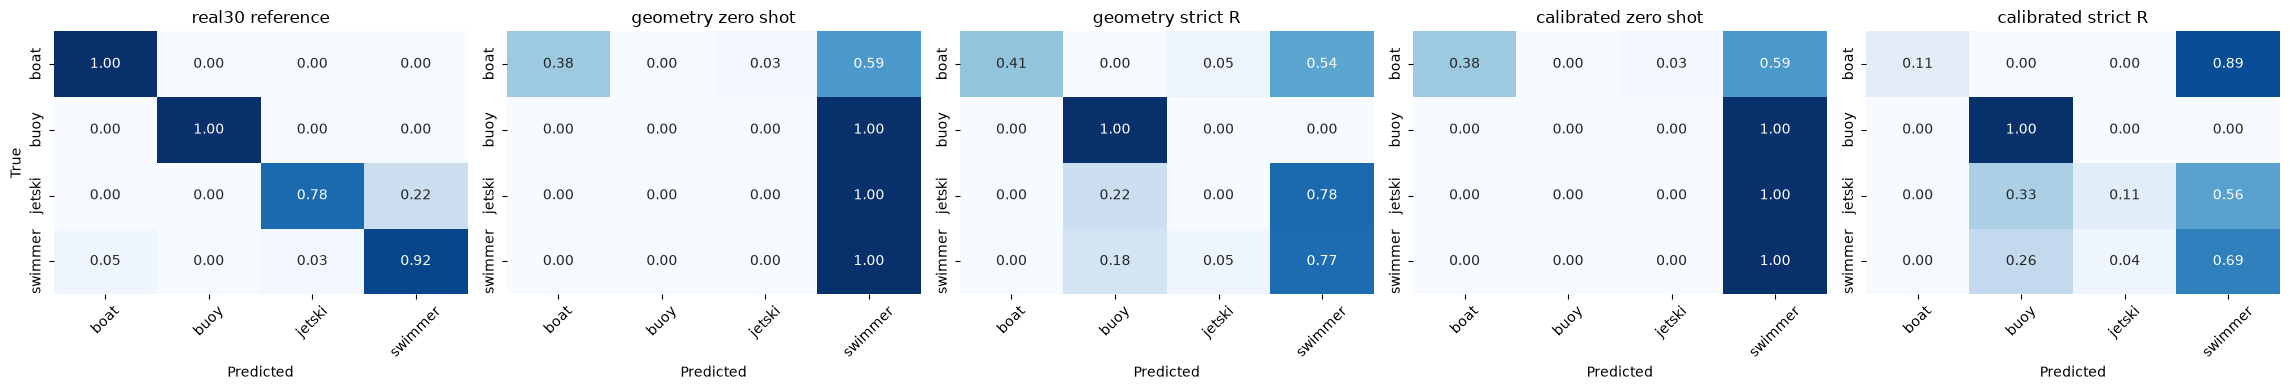

Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_synthetic80_procrustes_40\test_confusion_matrices.png


In [10]:
fig, axes = plt.subplots(1, 5, figsize=(23, 4))
for axis, (name, prediction) in zip(axes, predictions.items()):
    matrix = confusion_matrix(
        y_test,
        prediction,
        labels=np.arange(len(class_names)),
        normalize="true",
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        ax=axis,
    )
    axis.set_title(name.replace("_", " "))
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True" if axis is axes[0] else "")
    axis.tick_params(axis="x", rotation=45)
plt.tight_layout()
figure_path = RESULT_ROOT / "test_confusion_matrices.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", figure_path)

## 8. Inspect rank and singular-value support

Only the leading singular values are supported by the 40 calibration pairs. Values near numerical zero correspond to feature directions that the sample does not constrain. Orthogonality of the returned matrix does not resolve this identifiability problem.

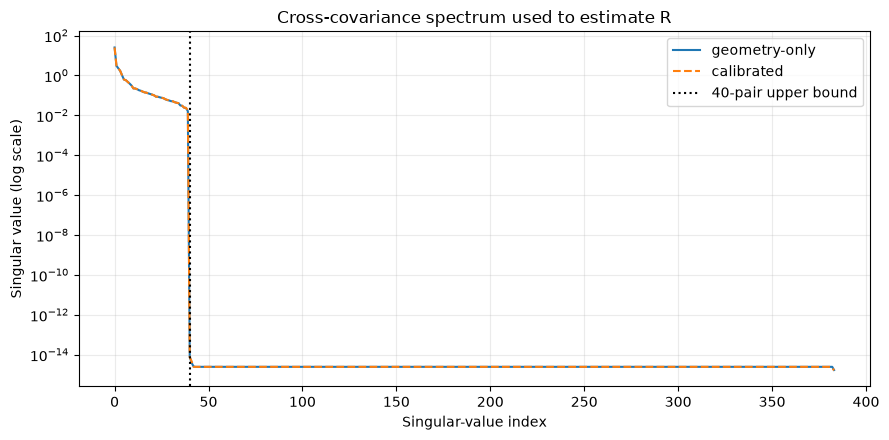

Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_synthetic80_procrustes_40\procrustes_singular_values.png


In [11]:
fig, axis = plt.subplots(figsize=(9, 4.5))
axis.semilogy(geometry_map.singular_values, label="geometry-only")
axis.semilogy(calibrated_map.singular_values, label="calibrated", linestyle="--")
axis.axvline(PAIRS_PER_CLASS * len(class_names), color="black", linestyle=":", label="40-pair upper bound")
axis.set_xlabel("Singular-value index")
axis.set_ylabel("Singular value (log scale)")
axis.set_title("Cross-covariance spectrum used to estimate R")
axis.legend()
axis.grid(alpha=0.25)
plt.tight_layout()
spectrum_path = RESULT_ROOT / "procrustes_singular_values.png"
fig.savefig(spectrum_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", spectrum_path)

## 9. Save a reproducible experiment bundle

The bundle contains the two mappings, the leakage-controlled fixed 30 m probe, class order, calibration object identifiers, and experimental metadata. It does not contain the frozen encoder weights; those remain the locally cached `facebook/dinov2-small` model.

In [12]:
prediction_table = test_pairs[[
    "pair_id", "object_key", "image_key", "category_name", "video", "frame_no"
]].copy()
prediction_table["true_label_index"] = y_test
for name, prediction in predictions.items():
    prediction_table[f"prediction_{name}"] = [class_names[index] for index in prediction]
prediction_table.to_csv(RESULT_ROOT / "test_predictions.csv", index=False)

bundle = {
    "model_name": MODEL_NAME,
    "feature_dimension": int(X30_calibration.shape[1]),
    "mapping_direction": "synthetic_80m_to_real_30m",
    "procrustes_type": "strict_uncentred_orthogonal",
    "pairs_per_class": PAIRS_PER_CLASS,
    "calibration_pair_ids": calibration_pairs["pair_id"].tolist(),
    "class_names": class_names,
    "label_to_index": label_to_index,
    "R_geometry": geometry_map.R,
    "R_calibrated": calibrated_map.R,
    "singular_values_geometry": geometry_map.singular_values,
    "singular_values_calibrated": calibrated_map.singular_values,
    "fixed_30m_probe_excluding_calibration_pairs": fixed_probe,
    "selected_C": selected_c,
    "random_seed": SEED,
}
joblib.dump(bundle, RESULT_ROOT / "procrustes_40pair_bundle.joblib")

result_summary = {
    "experiment": "synthetic80_to_real30_strict_procrustes_40pair_pilot",
    "status": "exploratory_due_to_rank_limit",
    "calibration_pairs": int(len(calibration_pairs)),
    "pairs_per_class": PAIRS_PER_CLASS,
    "feature_dimension": int(X30_calibration.shape[1]),
    "geometry_constrained_rank": geometry_map.constrained_rank,
    "calibrated_constrained_rank": calibrated_map.constrained_rank,
    "test_objects": int(len(test_pairs)),
    "test_class_counts": test_pairs["category_name"].value_counts().to_dict(),
    "classification_metrics": metrics.reset_index().to_dict("records"),
    "alignment_metrics": alignment_table.to_dict("records"),
    "transfer_decisions": transfer_decisions.reset_index().to_dict("records"),
    "interpretation": (
        "Neither strict 40-pair mapping passed the synthetic held-out transfer gate. "
        "A larger or reduced-dimensional calibration study is required before evaluation "
        "on untouched genuine 80 m imagery."
    ),
}
(RESULT_ROOT / "result_summary.json").write_text(
    json.dumps(result_summary, indent=2) + "\n", encoding="utf-8"
)

print("Saved experiment bundle and result tables to:", RESULT_ROOT)

Saved experiment bundle and result tables to: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_synthetic80_procrustes_40


## Pilot outcome

The decision gate requires all three held-out changes to move in the expected direction: macro-F1 must increase, paired cosine similarity must increase, and RMSE must decrease.

The current strict mappings do **not** pass this gate. They align the 40 calibration pairs strongly, but decrease feature alignment on unseen synthetic objects. This is evidence of calibration-set overfitting rather than a transferable 80 m → 30 m rotation. The matrices are retained as pilot artifacts, but they should not be promoted to the genuine 80 m evaluation as the final method.

The next justified experiment is a calibration-size and dimensionality study using development data only. A full 384×384 rotation should not be treated as identified from 40 pairs.

## 10. Larger calibration-size experiment

The 40-pair result may fail because it constrains only 40 directions in a 384-dimensional representation. This extension repeats the strict mapping experiment using nested training subsets of:

\[
40,\ 80,\ 160,\ 320,\ 640,\ 1010\text{ pairs}.
\]

All mappings use only the synthetic **training** partition. The same synthetic test partition and the same fixed probe are used at every size. To keep the comparison leakage-controlled, this new probe excludes all 1,010 objects that could be used to estimate any mapping.

The 1,010 pairs are not 1,010 independent flight scenes: multiple objects can come from the same image. Counts of unique images and videos are reported so sample size is not confused with independent environmental diversity.

Because the synthetic test results have already been inspected in the 40-pair pilot, this curve is a development diagnostic. Genuine real 80 m imagery remains the final external evaluation.

In [13]:
train_pairs_all = pairs[pairs["split"] == "train"].copy()
assert len(train_pairs_all) == 1010
assert not set(train_pairs_all["object_key"]) & set(test_pairs["object_key"])


def stable_hash(text, seed=SEED):
    digest = hashlib.sha256(f"{seed}:{text}".encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "little")


def progressive_class_order(frame):
    """Interleave classes; within each class prefer new source images first."""
    queues = {}
    for class_name, group in frame.groupby("category_name", sort=True):
        group = group.copy()
        group["_hash"] = group["pair_id"].map(stable_hash)
        group = group.sort_values("_hash")
        group["_repeat_within_image"] = group.groupby("image_key").cumcount()
        group = group.sort_values(["_repeat_within_image", "_hash"])
        queues[class_name] = group.drop(columns=["_hash", "_repeat_within_image"]).to_dict("records")

    ordered = []
    class_names_local = sorted(queues)
    while any(queues.values()):
        for class_name in class_names_local:
            if queues[class_name]:
                ordered.append(queues[class_name].pop(0))
    return pd.DataFrame(ordered)


large_calibration_pairs = progressive_class_order(train_pairs_all)
assert len(large_calibration_pairs) == len(train_pairs_all)
assert large_calibration_pairs["pair_id"].is_unique
large_calibration_pairs.to_csv(RESULT_ROOT / "large_calibration_pairs_ordered.csv", index=False)

# One fixed probe for the entire size curve: exclude the union of all R-fitting objects.
large_mapping_keys = set(large_calibration_pairs["object_key"])
large_probe_keep = ~meta_development["object_key"].isin(large_mapping_keys).to_numpy()
large_fixed_probe = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=selected_c,
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
    ),
)
large_fixed_probe.fit(X_development[large_probe_keep], y_development[large_probe_keep])

remaining_probe_labels = pd.Series(
    y_development[large_probe_keep]
).map(dict(enumerate(class_names))).value_counts().reindex(class_names, fill_value=0)
print("Mapping pairs:", len(large_calibration_pairs))
print("Unique mapping images:", large_calibration_pairs["image_key"].nunique())
print("Unique mapping videos:", large_calibration_pairs["video"].nunique())
print("Real 30 m objects retained for fixed probe:", int(large_probe_keep.sum()))
print("Remaining probe-training class counts:")
display(remaining_probe_labels.to_frame("objects"))
print("Mapping-pair class counts:")
display(large_calibration_pairs["category_name"].value_counts().reindex(class_names).to_frame("pairs"))

Mapping pairs: 1010
Unique mapping images: 251
Unique mapping videos: 7
Real 30 m objects retained for fixed probe: 1856
Remaining probe-training class counts:


,objects
boat,540
buoy,162
jetski,110
swimmer,1044


Mapping-pair class counts:


,pairs
category_name,
boat,126
buoy,49
jetski,9
swimmer,826


### Extract all 1,010 paired synthetic training features

The features are cached after the first run. The real 30 m targets come from the original feature cache, while the two synthetic variants pass through the same frozen encoder.

In [14]:
X30_large_calibration, y_large_calibration = lookup_real30_features(large_calibration_pairs)
X80_geometry_large = extract_synthetic_features(
    large_calibration_pairs,
    "geometry_image_path",
    "train1010_geometry",
)
X80_calibrated_large = extract_synthetic_features(
    large_calibration_pairs,
    "calibrated_image_path",
    "train1010_calibrated",
)
assert np.array_equal(y_large_calibration, large_calibration_pairs["category_name"].map(label_to_index))
print("Large paired feature matrices:", X30_large_calibration.shape)

Loaded cache: train1010_geometry.npz
Loaded cache: train1010_calibrated.npz
Large paired feature matrices: (1010, 384)


### Fit nested strict mappings

The first six rows below use ordinary unweighted Orthogonal Procrustes. A final full-dataset class-balanced fit is also evaluated because the available mapping pairs are dominated by swimmers. The weighted solution remains orthogonal; it changes only how strongly each class contributes to the cross-covariance matrix.

In [15]:
def fit_weighted_strict_procrustes(X_source_80, X_target_30, sample_weights):
    source = np.asarray(X_source_80, dtype=np.float64)
    target = np.asarray(X_target_30, dtype=np.float64)
    weights = np.asarray(sample_weights, dtype=np.float64)
    if source.shape != target.shape or len(weights) != len(source):
        raise ValueError("Feature matrices and sample weights do not match.")
    if np.any(weights <= 0):
        raise ValueError("All sample weights must be positive.")
    root_weights = np.sqrt(weights / weights.mean())[:, None]
    U, singular_values, Vt = np.linalg.svd(
        (source * root_weights).T @ (target * root_weights),
        full_matrices=False,
    )
    return StrictOrthogonalMap(R=U @ Vt, singular_values=singular_values)


def classification_row(probe, true_labels, predicted_labels):
    return {
        "accuracy": accuracy_score(true_labels, predicted_labels),
        "balanced_accuracy": balanced_accuracy_score(true_labels, predicted_labels),
        "macro_f1": f1_score(
            true_labels,
            predicted_labels,
            labels=np.arange(len(class_names)),
            average="macro",
            zero_division=0,
        ),
    }


large_zero_shot_features = {
    "real30_reference": X30_test,
    "geometry_zero_shot": X80_geometry_test,
    "calibrated_zero_shot": X80_calibrated_test,
}
large_zero_shot_rows = []
for arm, features in large_zero_shot_features.items():
    prediction = large_fixed_probe.predict(features)
    large_zero_shot_rows.append({"arm": arm, **classification_row(large_fixed_probe, y_test, prediction)})
large_zero_shot_metrics = pd.DataFrame(large_zero_shot_rows).set_index("arm")
large_zero_shot_metrics.to_csv(RESULT_ROOT / "large_experiment_zero_shot_metrics.csv")
display(large_zero_shot_metrics.style.format("{:.4f}"))

calibration_sizes = [40, 80, 160, 320, 640, len(large_calibration_pairs)]
large_result_rows = []
fitted_large_maps = {}
variant_data = {
    "geometry": (X80_geometry_large, X80_geometry_test),
    "calibrated": (X80_calibrated_large, X80_calibrated_test),
}

for size in calibration_sizes:
    subset_classes = large_calibration_pairs.iloc[:size]["category_name"]
    for variant, (X_cal_all, X_test_variant) in variant_data.items():
        fitted_map = fit_strict_procrustes(X_cal_all[:size], X30_large_calibration[:size])
        corrected_test = fitted_map.transform(X_test_variant)
        prediction = large_fixed_probe.predict(corrected_test)
        align = alignment_metrics(corrected_test, X30_test)
        baseline = large_zero_shot_metrics.loc[f"{variant}_zero_shot"]
        row = {
            "variant": variant,
            "calibration_pairs": size,
            "weighting": "unweighted",
            "constrained_rank": fitted_map.constrained_rank,
            "calibration_images": large_calibration_pairs.iloc[:size]["image_key"].nunique(),
            "calibration_videos": large_calibration_pairs.iloc[:size]["video"].nunique(),
            "minimum_class_pairs": int(subset_classes.value_counts().min()),
            **classification_row(large_fixed_probe, y_test, prediction),
            "heldout_rmse": align["rmse"],
            "heldout_paired_cosine": align["mean_paired_cosine"],
        }
        row["macro_f1_change_vs_zero_shot"] = row["macro_f1"] - baseline["macro_f1"]
        large_result_rows.append(row)
        fitted_large_maps[(variant, size, "unweighted")] = fitted_map

# Full-dataset inverse-frequency class weights.
class_counts = large_calibration_pairs["category_name"].value_counts()
class_weights = large_calibration_pairs["category_name"].map(lambda name: 1.0 / class_counts[name]).to_numpy()
for variant, (X_cal_all, X_test_variant) in variant_data.items():
    fitted_map = fit_weighted_strict_procrustes(X_cal_all, X30_large_calibration, class_weights)
    corrected_test = fitted_map.transform(X_test_variant)
    prediction = large_fixed_probe.predict(corrected_test)
    align = alignment_metrics(corrected_test, X30_test)
    baseline = large_zero_shot_metrics.loc[f"{variant}_zero_shot"]
    row = {
        "variant": variant,
        "calibration_pairs": len(large_calibration_pairs),
        "weighting": "class_balanced",
        "constrained_rank": fitted_map.constrained_rank,
        "calibration_images": large_calibration_pairs["image_key"].nunique(),
        "calibration_videos": large_calibration_pairs["video"].nunique(),
        "minimum_class_pairs": int(class_counts.min()),
        **classification_row(large_fixed_probe, y_test, prediction),
        "heldout_rmse": align["rmse"],
        "heldout_paired_cosine": align["mean_paired_cosine"],
    }
    row["macro_f1_change_vs_zero_shot"] = row["macro_f1"] - baseline["macro_f1"]
    large_result_rows.append(row)
    fitted_large_maps[(variant, len(large_calibration_pairs), "class_balanced")] = fitted_map

large_results = pd.DataFrame(large_result_rows)
large_results["passes_transfer_gate"] = (
    (large_results["macro_f1_change_vs_zero_shot"] > 0)
    & (large_results["heldout_paired_cosine"] > large_results["variant"].map({
        "geometry": alignment_metrics(X80_geometry_test, X30_test)["mean_paired_cosine"],
        "calibrated": alignment_metrics(X80_calibrated_test, X30_test)["mean_paired_cosine"],
    }))
    & (large_results["heldout_rmse"] < large_results["variant"].map({
        "geometry": alignment_metrics(X80_geometry_test, X30_test)["rmse"],
        "calibrated": alignment_metrics(X80_calibrated_test, X30_test)["rmse"],
    }))
)
large_results.to_csv(RESULT_ROOT / "large_calibration_size_results.csv", index=False)
display(large_results.style.format({
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "macro_f1_change_vs_zero_shot": "{:+.4f}",
    "heldout_rmse": "{:.5f}",
    "heldout_paired_cosine": "{:.4f}",
}))

,accuracy,balanced_accuracy,macro_f1
arm,,,
real30_reference,0.9273,0.9513,0.8228
geometry_zero_shot,0.8545,0.3041,0.3191
calibrated_zero_shot,0.8509,0.2973,0.3098


,variant,calibration_pairs,weighting,constrained_rank,calibration_images,calibration_videos,minimum_class_pairs,accuracy,balanced_accuracy,macro_f1,heldout_rmse,heldout_paired_cosine,macro_f1_change_vs_zero_shot,passes_transfer_gate
0,geometry,40,unweighted,40,39,6,9,0.7818,0.3555,0.3373,0.03844,0.7163,+0.0182,False
1,calibrated,40,unweighted,40,39,6,9,0.7564,0.4095,0.4179,0.03870,0.7124,+0.1081,False
2,geometry,80,unweighted,80,73,6,9,0.8000,0.4284,0.4705,0.03791,0.7241,+0.1514,False
3,calibrated,80,unweighted,80,73,6,9,0.7564,0.2800,0.2778,0.03795,0.7234,-0.0319,False
4,geometry,160,unweighted,160,143,7,9,0.7527,0.3858,0.4237,0.03770,0.7271,+0.1045,False
5,calibrated,160,unweighted,160,143,7,9,0.7782,0.4218,0.4623,0.03766,0.7277,+0.1525,False
6,geometry,320,unweighted,320,210,7,9,0.7782,0.2696,0.2664,0.03732,0.7326,-0.0527,False
7,calibrated,320,unweighted,320,210,7,9,0.7745,0.2629,0.2590,0.03724,0.7337,-0.0508,False
8,geometry,640,unweighted,383,251,7,9,0.8182,0.2535,0.2382,0.03661,0.7427,-0.0809,False
9,calibrated,640,unweighted,384,251,7,9,0.8182,0.2535,0.2382,0.03657,0.7432,-0.0716,False


### Calibration-size curves

A useful larger mapping must improve task performance and paired feature alignment on unseen objects. Rank alone is insufficient: once the cross-covariance becomes full-rank, the estimated rotation can still represent a dataset-specific relationship that does not transfer.

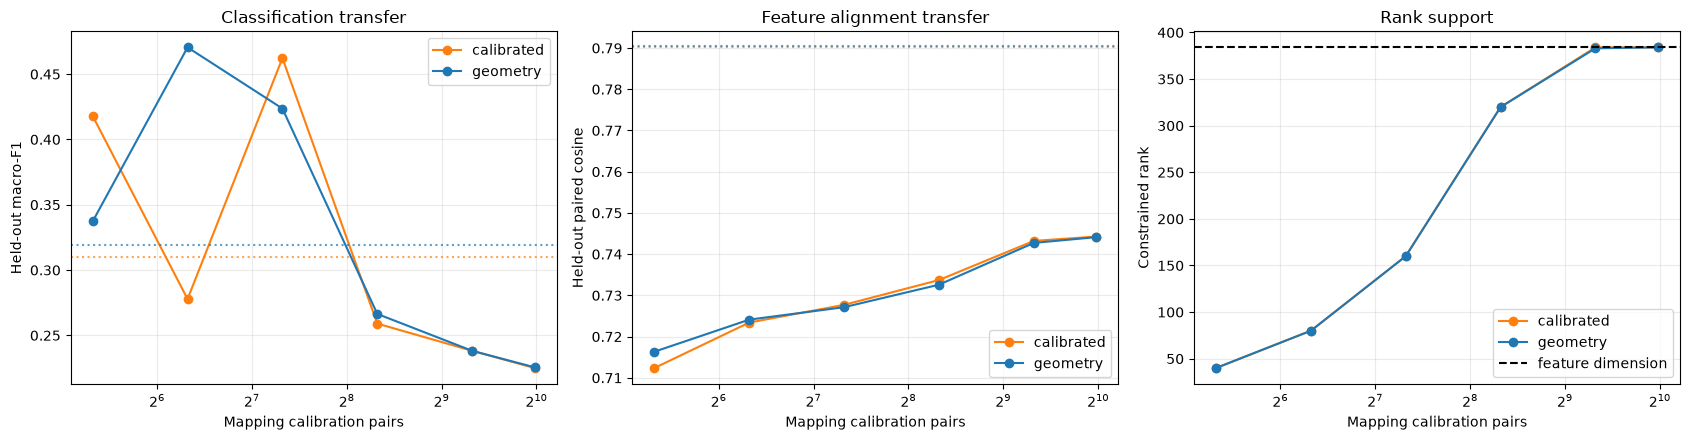

Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_synthetic80_procrustes_40\large_calibration_size_curves.png


In [16]:
unweighted_results = large_results[large_results["weighting"] == "unweighted"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
colours = {"geometry": "tab:blue", "calibrated": "tab:orange"}
for variant, group in unweighted_results.groupby("variant"):
    group = group.sort_values("calibration_pairs")
    axes[0].plot(group["calibration_pairs"], group["macro_f1"], marker="o", label=variant, color=colours[variant])
    axes[1].plot(group["calibration_pairs"], group["heldout_paired_cosine"], marker="o", label=variant, color=colours[variant])
    axes[2].plot(group["calibration_pairs"], group["constrained_rank"], marker="o", label=variant, color=colours[variant])
    axes[0].axhline(
        large_zero_shot_metrics.loc[f"{variant}_zero_shot", "macro_f1"],
        color=colours[variant], linestyle=":", alpha=0.7,
    )
    raw_cosine = alignment_metrics(
        X80_geometry_test if variant == "geometry" else X80_calibrated_test,
        X30_test,
    )["mean_paired_cosine"]
    axes[1].axhline(raw_cosine, color=colours[variant], linestyle=":", alpha=0.7)

for axis in axes:
    axis.set_xscale("log", base=2)
    axis.set_xlabel("Mapping calibration pairs")
    axis.grid(alpha=0.25)
axes[0].set_ylabel("Held-out macro-F1")
axes[0].set_title("Classification transfer")
axes[1].set_ylabel("Held-out paired cosine")
axes[1].set_title("Feature alignment transfer")
axes[2].set_ylabel("Constrained rank")
axes[2].set_title("Rank support")
axes[2].axhline(X30_large_calibration.shape[1], color="black", linestyle="--", label="feature dimension")
axes[0].legend()
axes[1].legend()
axes[2].legend()
plt.tight_layout()
curve_path = RESULT_ROOT / "large_calibration_size_curves.png"
fig.savefig(curve_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", curve_path)

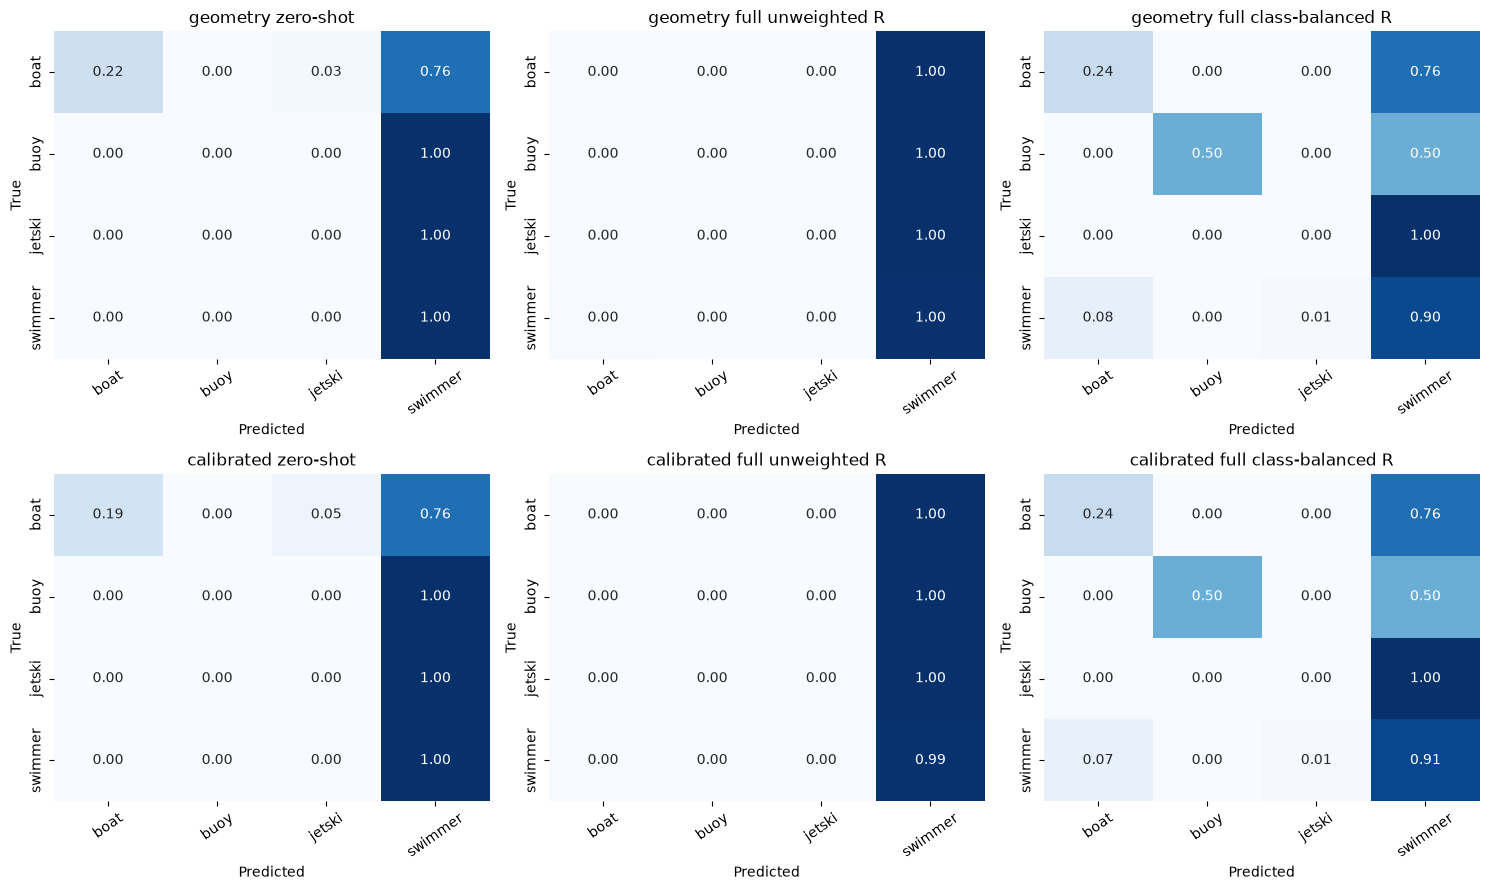

Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_synthetic80_procrustes_40\large_full_mapping_confusions.png


In [17]:
large_comparison_features = {
    "geometry zero-shot": X80_geometry_test,
    "geometry full unweighted R": fitted_large_maps[("geometry", 1010, "unweighted")].transform(X80_geometry_test),
    "geometry full class-balanced R": fitted_large_maps[("geometry", 1010, "class_balanced")].transform(X80_geometry_test),
    "calibrated zero-shot": X80_calibrated_test,
    "calibrated full unweighted R": fitted_large_maps[("calibrated", 1010, "unweighted")].transform(X80_calibrated_test),
    "calibrated full class-balanced R": fitted_large_maps[("calibrated", 1010, "class_balanced")].transform(X80_calibrated_test),
}
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, (name, features) in zip(axes.flat, large_comparison_features.items()):
    prediction = large_fixed_probe.predict(features)
    matrix = confusion_matrix(
        y_test, prediction,
        labels=np.arange(len(class_names)),
        normalize="true",
    )
    sns.heatmap(
        matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
        xticklabels=class_names, yticklabels=class_names, cbar=False, ax=axis,
    )
    axis.set_title(name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True")
    axis.tick_params(axis="x", rotation=35)
plt.tight_layout()
large_confusion_path = RESULT_ROOT / "large_full_mapping_confusions.png"
fig.savefig(large_confusion_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", large_confusion_path)

### Observed larger-dataset outcome

Increasing the number of pairs removed the original rank deficiency, but it did not produce a consistently transferable strict rotation.

- Geometry-only reached its highest diagnostic macro-F1 at 80 pairs: **0.4705**, compared with its zero-shot baseline of **0.3191**.
- Calibrated imagery reached its highest unweighted diagnostic macro-F1 at 160 pairs: **0.4623**, compared with **0.3098** zero-shot.
- Using all 1,010 pairs without weighting reduced macro-F1 to approximately **0.225** for both variants.
- Full-data class balancing recovered macro-F1 to **0.4540** for geometry-only and **0.4574** for calibrated imagery.
- However, every corrected feature set remained less aligned with its paired real 30 m target than the uncorrected features. The best corrected paired cosine remained below the uncorrected value of approximately **0.790**.

Therefore, more pairs can improve class-balanced prediction relative to zero-shot in selected configurations, but **more data alone does not validate the single strict orthogonal mapping hypothesis**. The non-monotonic F1 curve, sensitivity to class weighting, and degraded paired alignment suggest that the improvement is task-specific rather than evidence that (R) correctly recovers the real 30 m feature geometry.

### Save the full-dataset mappings and decision

The matrices are saved even when they fail the transfer gate so the experiment remains reproducible. A failed mapping should not be applied to genuine 80 m data as if it were validated.

In [18]:
for variant in ["geometry", "calibrated"]:
    for weighting in ["unweighted", "class_balanced"]:
        fitted_map = fitted_large_maps[(variant, len(large_calibration_pairs), weighting)]
        np.save(RESULT_ROOT / f"R_{variant}_strict_1010_{weighting}.npy", fitted_map.R)

large_bundle = {
    "model_name": MODEL_NAME,
    "mapping_direction": "synthetic_80m_to_real_30m",
    "procrustes_type": "strict_uncentred_orthogonal",
    "feature_dimension": int(X30_large_calibration.shape[1]),
    "calibration_pairs": int(len(large_calibration_pairs)),
    "calibration_unique_images": int(large_calibration_pairs["image_key"].nunique()),
    "calibration_unique_videos": int(large_calibration_pairs["video"].nunique()),
    "pair_ids_in_order": large_calibration_pairs["pair_id"].tolist(),
    "fixed_30m_probe_excluding_all_mapping_pairs": large_fixed_probe,
    "class_names": class_names,
    "selected_C": selected_c,
    "R_geometry_unweighted": fitted_large_maps[("geometry", len(large_calibration_pairs), "unweighted")].R,
    "R_calibrated_unweighted": fitted_large_maps[("calibrated", len(large_calibration_pairs), "unweighted")].R,
    "R_geometry_class_balanced": fitted_large_maps[("geometry", len(large_calibration_pairs), "class_balanced")].R,
    "R_calibrated_class_balanced": fitted_large_maps[("calibrated", len(large_calibration_pairs), "class_balanced")].R,
}
joblib.dump(large_bundle, RESULT_ROOT / "procrustes_1010pair_bundle.joblib")

best_by_variant = (
    large_results.sort_values(["variant", "macro_f1"], ascending=[True, False])
    .groupby("variant", as_index=False)
    .head(1)
)
print("Best diagnostic result for each variant (selected after inspecting synthetic test):")
display(best_by_variant[[
    "variant", "calibration_pairs", "weighting", "macro_f1",
    "macro_f1_change_vs_zero_shot", "heldout_paired_cosine",
    "heldout_rmse", "passes_transfer_gate",
]])

large_summary = {
    "experiment": "synthetic80_to_real30_strict_procrustes_calibration_size_extension",
    "calibration_sizes": calibration_sizes,
    "maximum_calibration_pairs": int(len(large_calibration_pairs)),
    "maximum_unique_images": int(large_calibration_pairs["image_key"].nunique()),
    "maximum_unique_videos": int(large_calibration_pairs["video"].nunique()),
    "probe_training_objects_after_exclusion": int(large_probe_keep.sum()),
    "zero_shot_metrics": large_zero_shot_metrics.reset_index().to_dict("records"),
    "results": large_results.to_dict("records"),
    "any_mapping_passed_transfer_gate": bool(large_results["passes_transfer_gate"].any()),
    "note": (
        "Synthetic test has already been inspected and is now development evidence. "
        "Genuine real 80 m imagery remains the external test."
    ),
}
(RESULT_ROOT / "large_calibration_summary.json").write_text(
    json.dumps(large_summary, indent=2) + "\n", encoding="utf-8"
)
print("Saved large-calibration artifacts to:", RESULT_ROOT)

Best diagnostic result for each variant (selected after inspecting synthetic test):


,variant,calibration_pairs,weighting,macro_f1,macro_f1_change_vs_zero_shot,heldout_paired_cosine,heldout_rmse,passes_transfer_gate
5,calibrated,160,unweighted,0.462274,0.152505,0.727703,0.037659,False
2,geometry,80,unweighted,0.470505,0.151393,0.724116,0.037906,False


Saved large-calibration artifacts to: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_synthetic80_procrustes_40


### How to interpret the extension

Increasing the number of pairs answers a specific question: was the 40-pair failure mainly caused by insufficient rank support?

- If held-out macro-F1 and paired alignment rise above their zero-shot baselines as calibration size grows, the orthogonal hypothesis gains preliminary synthetic support.
- If the calibration matrix becomes full-rank but held-out performance remains worse, insufficient sample rank was not the only problem. A single strict global rotation may be the wrong model, or the synthetic transformation may not reproduce a consistent feature displacement.
- The class-balanced result is diagnostic because the available pairs are highly imbalanced. It must be reported separately from ordinary Procrustes.

No result in this section constitutes genuine 80 m evidence.

## 11. Reduced-dimensional orthogonal correction

An orthogonal matrix is always full-rank, so directly making (R) rank-deficient would no longer be Orthogonal Procrustes. The appropriate constrained alternative is to learn a rotation only inside a (k)-dimensional feature subspace and leave its orthogonal complement unchanged.

Let (P_k\in\mathbb{R}^{384\times k}) contain orthonormal feature directions learned from mapping-calibration data only. Fit (R_k\in\mathbb{R}^{k\times k}) by Orthogonal Procrustes, then transform a feature row vector as

\[
\hat z_{30}
=
\underbrace{z_{80}(I-P_kP_k^T)}_{\text{unchanged complement}}
+
\underbrace{z_{80}P_kR_kP_k^T}_{\text{learned subspace rotation}}.
\]

The equivalent 384-dimensional operator remains orthogonal and full-rank, but only (k) directions receive a learned correction. This prevents the calibration set from arbitrarily rotating unsupported directions.

The subspace basis is obtained by uncentred SVD of the stacked synthetic-80 and real-30 calibration features. No mean translation is introduced, so this remains a constrained version of Arm C rather than Arm D.

### Leakage-controlled development protocol

- Fit the subspace and (R_k) using all 1,010 synthetic **training** pairs.
- Choose (k) using the 180 paired synthetic **validation** objects.
- Evaluate the chosen configuration on the 275 synthetic **test** objects.
- Train one fixed 30 m probe after excluding every paired training and validation object used by this experiment.

Although this creates a clean internal selection protocol, the synthetic test partition has been viewed in earlier experiments. It remains development evidence; genuine real 80 m data is still the external test.

In [19]:
validation_pairs = pairs[pairs["split"] == "val"].sort_values("pair_id").reset_index(drop=True)
X30_validation, y_validation = lookup_real30_features(validation_pairs)
X80_geometry_validation = extract_synthetic_features(
    validation_pairs, "geometry_image_path", "validation_geometry"
)
X80_calibrated_validation = extract_synthetic_features(
    validation_pairs, "calibrated_image_path", "validation_calibrated"
)

# Exclude every object used for mapping fit or subspace-dimension selection.
subspace_excluded_keys = set(large_calibration_pairs["object_key"]) | set(validation_pairs["object_key"])
subspace_probe_keep = ~meta_development["object_key"].isin(subspace_excluded_keys).to_numpy()
subspace_fixed_probe = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=selected_c,
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
    ),
)
subspace_fixed_probe.fit(
    X_development[subspace_probe_keep],
    y_development[subspace_probe_keep],
)

subspace_probe_counts = pd.Series(
    y_development[subspace_probe_keep]
).map(dict(enumerate(class_names))).value_counts().reindex(class_names, fill_value=0)
print("Validation pairs:", len(validation_pairs))
print("30 m objects retained for the fixed probe:", int(subspace_probe_keep.sum()))
print("Excluded mapping/development objects:", int((~subspace_probe_keep).sum()))
display(subspace_probe_counts.to_frame("probe_training_objects"))

Loaded cache: validation_geometry.npz
Loaded cache: validation_calibrated.npz
Validation pairs: 180
30 m objects retained for the fixed probe: 1676
Excluded mapping/development objects: 1190


,probe_training_objects
boat,521
buoy,159
jetski,94
swimmer,902


### Fit subspace mappings and select (k)

Candidate dimensions range from 4 to 384. Both ordinary and inverse-class-frequency weighted fits are inspected because the 1,010 calibration pairs contain only nine jet skis but 826 swimmers.

Selection first looks for configurations that improve validation macro-F1, paired cosine similarity, and RMSE over the corresponding zero-shot validation baseline. If none pass all three conditions, the best macro-F1 configuration is reported only as a diagnostic failure.

In [20]:
@dataclass(frozen=True)
class SubspaceOrthogonalMap:
    basis: np.ndarray
    R_subspace: np.ndarray

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        coordinates = X @ self.basis
        residual = X - coordinates @ self.basis.T
        return residual + (coordinates @ self.R_subspace) @ self.basis.T

    def full_operator(self):
        identity = np.eye(self.basis.shape[0])
        projector = self.basis @ self.basis.T
        return identity - projector + self.basis @ self.R_subspace @ self.basis.T

    @property
    def orthogonality_error(self):
        Q = self.full_operator()
        return float(np.linalg.norm(Q.T @ Q - np.eye(Q.shape[0]), ord="fro"))


def fit_uncentred_basis(X_source, X_target, sample_weights=None):
    source = np.asarray(X_source, dtype=np.float64)
    target = np.asarray(X_target, dtype=np.float64)
    if sample_weights is None:
        weights = np.ones(len(source), dtype=np.float64)
    else:
        weights = np.asarray(sample_weights, dtype=np.float64)
    root_weights = np.sqrt(weights / weights.mean())[:, None]
    stacked = np.vstack([source * root_weights, target * root_weights])
    _, singular_values, Vt = np.linalg.svd(stacked, full_matrices=False)
    return Vt.T, singular_values


def fit_subspace_orthogonal_map(X_source, X_target, full_basis, dimension, sample_weights=None):
    basis = full_basis[:, :dimension]
    source_coordinates = np.asarray(X_source, dtype=np.float64) @ basis
    target_coordinates = np.asarray(X_target, dtype=np.float64) @ basis
    if sample_weights is None:
        fitted = fit_strict_procrustes(source_coordinates, target_coordinates)
    else:
        fitted = fit_weighted_strict_procrustes(
            source_coordinates, target_coordinates, sample_weights
        )
    return SubspaceOrthogonalMap(basis=basis, R_subspace=fitted.R)


def evaluate_feature_arm(probe, features, target_features, labels):
    prediction = probe.predict(features)
    return {
        **classification_row(probe, labels, prediction),
        **{f"alignment_{key}": value for key, value in alignment_metrics(features, target_features).items()},
    }


subspace_dimensions = [4, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 320, 384]
training_class_counts = large_calibration_pairs["category_name"].value_counts()
subspace_class_weights = large_calibration_pairs["category_name"].map(
    lambda name: 1.0 / training_class_counts[name]
).to_numpy()

subspace_variant_data = {
    "geometry": {
        "train": X80_geometry_large,
        "validation": X80_geometry_validation,
        "test": X80_geometry_test,
    },
    "calibrated": {
        "train": X80_calibrated_large,
        "validation": X80_calibrated_validation,
        "test": X80_calibrated_test,
    },
}

subspace_zero_shot_rows = []
for partition, target, labels, key in [
    ("validation", X30_validation, y_validation, "validation"),
    ("test", X30_test, y_test, "test"),
]:
    for variant, matrices in subspace_variant_data.items():
        result = evaluate_feature_arm(
            subspace_fixed_probe, matrices[key], target, labels
        )
        subspace_zero_shot_rows.append({
            "partition": partition,
            "variant": variant,
            **result,
        })
subspace_zero_shot = pd.DataFrame(subspace_zero_shot_rows)
subspace_zero_shot.to_csv(RESULT_ROOT / "subspace_zero_shot_metrics.csv", index=False)
display(subspace_zero_shot.style.format({
    "accuracy": "{:.4f}", "balanced_accuracy": "{:.4f}", "macro_f1": "{:.4f}",
    "alignment_rmse": "{:.5f}", "alignment_mean_paired_cosine": "{:.4f}",
}))

subspace_validation_rows = []
subspace_maps = {}
for variant, matrices in subspace_variant_data.items():
    for weighting in ["unweighted", "class_balanced"]:
        weights = None if weighting == "unweighted" else subspace_class_weights
        basis, basis_singular_values = fit_uncentred_basis(
            matrices["train"], X30_large_calibration, weights
        )
        for dimension in subspace_dimensions:
            fitted_map = fit_subspace_orthogonal_map(
                matrices["train"], X30_large_calibration,
                basis, dimension, weights,
            )
            corrected = fitted_map.transform(matrices["validation"])
            result = evaluate_feature_arm(
                subspace_fixed_probe, corrected, X30_validation, y_validation
            )
            raw = subspace_zero_shot[
                (subspace_zero_shot["partition"] == "validation")
                & (subspace_zero_shot["variant"] == variant)
            ].iloc[0]
            subspace_validation_rows.append({
                "variant": variant,
                "weighting": weighting,
                "subspace_dimension": dimension,
                "orthogonality_error": fitted_map.orthogonality_error,
                **result,
                "macro_f1_change_vs_zero_shot": result["macro_f1"] - raw["macro_f1"],
                "cosine_change_vs_zero_shot": (
                    result["alignment_mean_paired_cosine"]
                    - raw["alignment_mean_paired_cosine"]
                ),
                "rmse_change_vs_zero_shot": (
                    result["alignment_rmse"] - raw["alignment_rmse"]
                ),
            })
            subspace_maps[(variant, weighting, dimension)] = fitted_map

subspace_validation_results = pd.DataFrame(subspace_validation_rows)
subspace_validation_results["passes_validation_gate"] = (
    (subspace_validation_results["macro_f1_change_vs_zero_shot"] > 0)
    & (subspace_validation_results["cosine_change_vs_zero_shot"] > 0)
    & (subspace_validation_results["rmse_change_vs_zero_shot"] < 0)
)
subspace_validation_results.to_csv(
    RESULT_ROOT / "subspace_validation_results.csv", index=False
)
display(subspace_validation_results.style.format({
    "macro_f1": "{:.4f}", "macro_f1_change_vs_zero_shot": "{:+.4f}",
    "alignment_rmse": "{:.5f}", "alignment_mean_paired_cosine": "{:.4f}",
    "cosine_change_vs_zero_shot": "{:+.4f}", "rmse_change_vs_zero_shot": "{:+.5f}",
    "orthogonality_error": "{:.2e}",
}))

,partition,variant,accuracy,balanced_accuracy,macro_f1,alignment_rmse,alignment_mean_paired_cosine
0,validation,geometry,0.8778,0.5535,0.5881,0.03102,0.8153
1,validation,calibrated,0.8833,0.6368,0.6638,0.03096,0.8160
2,test,geometry,0.8436,0.2838,0.2879,0.03303,0.7905
3,test,calibrated,0.8436,0.2838,0.2879,0.03306,0.7902


,variant,weighting,subspace_dimension,orthogonality_error,accuracy,balanced_accuracy,macro_f1,alignment_rmse,alignment_mean_paired_cosine,macro_f1_change_vs_zero_shot,cosine_change_vs_zero_shot,rmse_change_vs_zero_shot,passes_validation_gate
0,geometry,unweighted,4,9.31e-15,0.861111,0.443847,0.4509,0.02905,0.8379,-0.1372,+0.0227,-0.00197,False
1,geometry,unweighted,8,9.45e-15,0.872222,0.470163,0.4623,0.02790,0.8505,-0.1258,+0.0353,-0.00312,False
2,geometry,unweighted,16,1.06e-14,0.872222,0.470163,0.4623,0.02814,0.8479,-0.1258,+0.0327,-0.00288,False
3,geometry,unweighted,24,1.51e-14,0.872222,0.470163,0.4623,0.02895,0.8391,-0.1258,+0.0238,-0.00207,False
4,geometry,unweighted,32,1.56e-14,0.883333,0.555257,0.5587,0.02938,0.8342,-0.0294,+0.0190,-0.00164,False
5,geometry,unweighted,48,2.17e-14,0.877778,0.612275,0.6144,0.03036,0.8230,+0.0263,+0.0077,-0.00066,True
6,geometry,unweighted,64,2.76e-14,0.888889,0.708766,0.6771,0.03089,0.8168,+0.0890,+0.0015,-0.00013,True
7,geometry,unweighted,96,3.71e-14,0.894444,0.721924,0.6854,0.03161,0.8082,+0.0973,-0.0071,+0.00059,False
8,geometry,unweighted,128,4.64e-14,0.894444,0.721924,0.7211,0.03225,0.8004,+0.1330,-0.0149,+0.00123,False
9,geometry,unweighted,192,6.65e-14,0.883333,0.614035,0.6208,0.03276,0.7939,+0.0327,-0.0213,+0.00174,False


### Select on validation, then evaluate on synthetic test

The selected dimension is determined without using synthetic test metrics. Geometry-only and calibrated transformations are selected independently because their feature displacements may occupy different subspaces.

In [21]:
selected_subspace_rows = []
subspace_test_rows = []
for variant in ["geometry", "calibrated"]:
    candidates = subspace_validation_results[
        subspace_validation_results["variant"] == variant
    ].copy()
    passing = candidates[candidates["passes_validation_gate"]]
    if len(passing):
        selected = passing.sort_values(
            ["macro_f1", "alignment_mean_paired_cosine"], ascending=False
        ).iloc[0]
        selection_status = "passed_validation_gate"
    else:
        selected = candidates.sort_values(
            ["macro_f1", "alignment_mean_paired_cosine"], ascending=False
        ).iloc[0]
        selection_status = "diagnostic_only_no_gate_pass"

    weighting = str(selected["weighting"])
    dimension = int(selected["subspace_dimension"])
    fitted_map = subspace_maps[(variant, weighting, dimension)]
    corrected_test = fitted_map.transform(subspace_variant_data[variant]["test"])
    test_result = evaluate_feature_arm(
        subspace_fixed_probe, corrected_test, X30_test, y_test
    )
    raw_test = subspace_zero_shot[
        (subspace_zero_shot["partition"] == "test")
        & (subspace_zero_shot["variant"] == variant)
    ].iloc[0]
    test_gate = bool(
        test_result["macro_f1"] > raw_test["macro_f1"]
        and test_result["alignment_mean_paired_cosine"] > raw_test["alignment_mean_paired_cosine"]
        and test_result["alignment_rmse"] < raw_test["alignment_rmse"]
    )
    selected_subspace_rows.append({
        "variant": variant,
        "weighting": weighting,
        "subspace_dimension": dimension,
        "selection_status": selection_status,
        "validation_macro_f1": float(selected["macro_f1"]),
        "validation_macro_f1_change": float(selected["macro_f1_change_vs_zero_shot"]),
        "validation_paired_cosine": float(selected["alignment_mean_paired_cosine"]),
        "validation_gate": bool(selected["passes_validation_gate"]),
    })
    subspace_test_rows.append({
        "variant": variant,
        "weighting": weighting,
        "subspace_dimension": dimension,
        **test_result,
        "macro_f1_change_vs_zero_shot": test_result["macro_f1"] - raw_test["macro_f1"],
        "cosine_change_vs_zero_shot": (
            test_result["alignment_mean_paired_cosine"]
            - raw_test["alignment_mean_paired_cosine"]
        ),
        "rmse_change_vs_zero_shot": (
            test_result["alignment_rmse"] - raw_test["alignment_rmse"]
        ),
        "passes_test_gate": test_gate,
    })

selected_subspace = pd.DataFrame(selected_subspace_rows)
subspace_test_results = pd.DataFrame(subspace_test_rows)
selected_subspace.to_csv(RESULT_ROOT / "subspace_selected_models.csv", index=False)
subspace_test_results.to_csv(RESULT_ROOT / "subspace_test_results.csv", index=False)
print("Validation selections:")
display(selected_subspace)
print("Synthetic test results for validation-selected mappings:")
display(subspace_test_results.style.format({
    "accuracy": "{:.4f}", "balanced_accuracy": "{:.4f}", "macro_f1": "{:.4f}",
    "macro_f1_change_vs_zero_shot": "{:+.4f}",
    "alignment_rmse": "{:.5f}", "alignment_mean_paired_cosine": "{:.4f}",
    "cosine_change_vs_zero_shot": "{:+.4f}", "rmse_change_vs_zero_shot": "{:+.5f}",
}))

Validation selections:


,variant,weighting,subspace_dimension,selection_status,validation_macro_f1,validation_macro_f1_change,validation_paired_cosine,validation_gate
0,geometry,class_balanced,64,passed_validation_gate,0.716060,0.127997,0.822748,True
1,calibrated,class_balanced,64,passed_validation_gate,0.718962,0.055119,0.820890,True


Synthetic test results for validation-selected mappings:


,variant,weighting,subspace_dimension,accuracy,balanced_accuracy,macro_f1,alignment_rmse,alignment_mean_paired_cosine,macro_f1_change_vs_zero_shot,cosine_change_vs_zero_shot,rmse_change_vs_zero_shot,passes_test_gate
0,geometry,class_balanced,64,0.7564,0.4774,0.4937,0.03462,0.7699,+0.2058,-0.0206,+0.00159,False
1,calibrated,class_balanced,64,0.7818,0.4851,0.5064,0.03463,0.7698,+0.2185,-0.0204,+0.00157,False


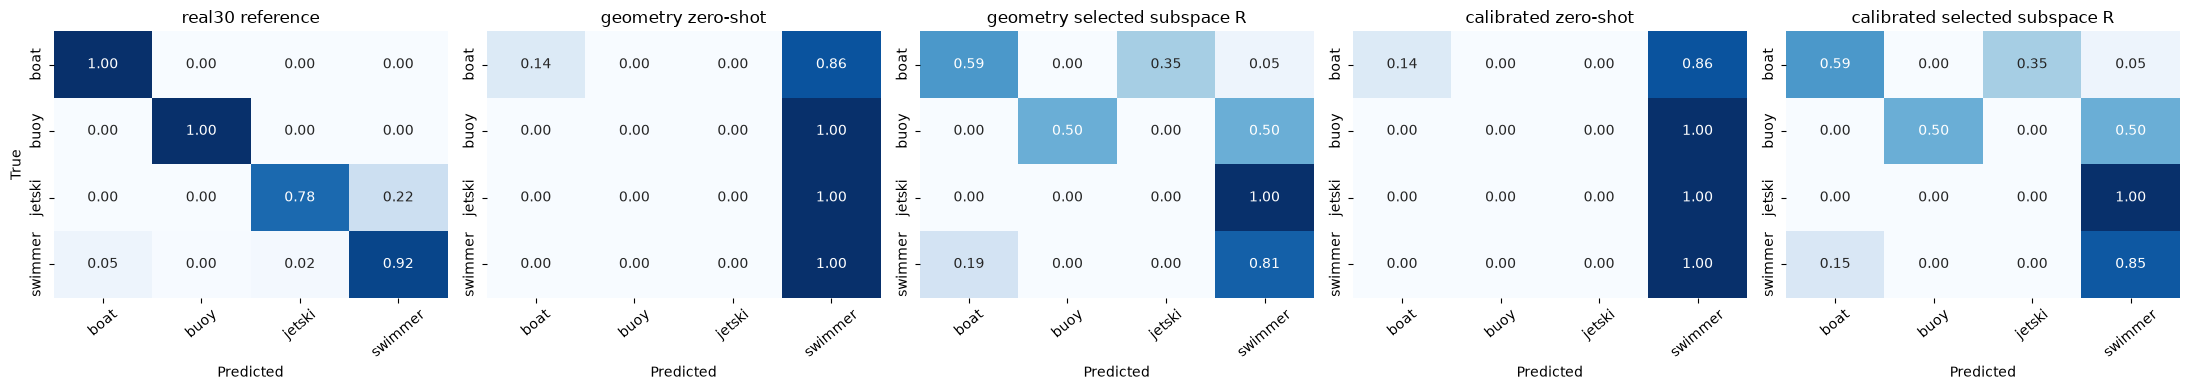

Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_synthetic80_procrustes_40\subspace_selected_test_confusions.png


In [22]:
selected_test_features = {"real30 reference": X30_test}
for variant in ["geometry", "calibrated"]:
    selected_row = selected_subspace[selected_subspace["variant"] == variant].iloc[0]
    key = (
        variant,
        str(selected_row["weighting"]),
        int(selected_row["subspace_dimension"]),
    )
    selected_test_features[f"{variant} zero-shot"] = subspace_variant_data[variant]["test"]
    selected_test_features[f"{variant} selected subspace R"] = subspace_maps[key].transform(
        subspace_variant_data[variant]["test"]
    )

fig, axes = plt.subplots(1, len(selected_test_features), figsize=(22, 4))
for axis, (name, features) in zip(axes, selected_test_features.items()):
    prediction = subspace_fixed_probe.predict(features)
    matrix = confusion_matrix(
        y_test, prediction,
        labels=np.arange(len(class_names)), normalize="true",
    )
    sns.heatmap(
        matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
        xticklabels=class_names, yticklabels=class_names,
        cbar=False, ax=axis,
    )
    axis.set_title(name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True" if axis is axes[0] else "")
    axis.tick_params(axis="x", rotation=40)
plt.tight_layout()
selected_confusion_path = RESULT_ROOT / "subspace_selected_test_confusions.png"
fig.savefig(selected_confusion_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", selected_confusion_path)

### Observed reduced-dimensional outcome

Validation selected a **64-dimensional, class-balanced** subspace rotation for both image variants. On the synthetic test objects:

| Test arm | Accuracy | Balanced accuracy | Macro-F1 | Paired cosine |
|---|---:|---:|---:|---:|
| Geometry zero-shot | 0.8436 | 0.2838 | 0.2879 | 0.7905 |
| Geometry selected (k=64) | 0.7564 | 0.4774 | 0.4937 | 0.7699 |
| Calibrated zero-shot | 0.8436 | 0.2838 | 0.2879 | 0.7902 |
| Calibrated selected (k=64) | 0.7818 | 0.4851 | 0.5064 | 0.7698 |

Reducing the learned subspace therefore substantially improves **balanced accuracy and macro-F1**, showing that it prevents some of the damaging full-space rotation. Ordinary accuracy decreases because the zero-shot model obtains high accuracy by predicting the dominant swimmer class for almost everything.

However, both selected mappings reduce paired cosine similarity and increase RMSE on the synthetic test set. Neither passes the complete transfer gate. The result supports a useful task-level correction, but it does not yet show that the mapping reconstructs the corresponding real 30 m feature geometry.

### Dimension-selection curves

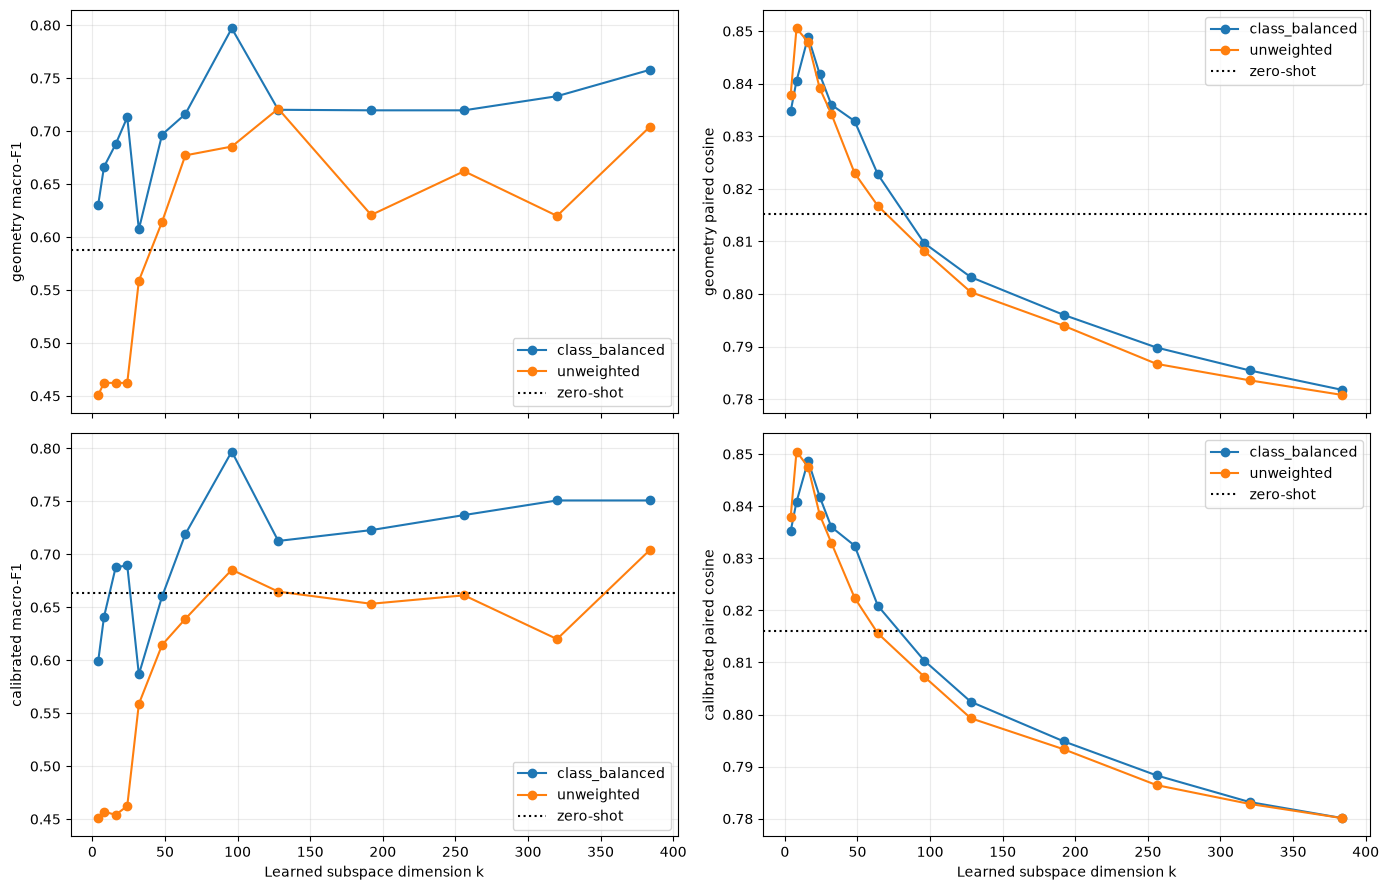

Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_synthetic80_procrustes_40\subspace_dimension_selection_curves.png


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for row_index, variant in enumerate(["geometry", "calibrated"]):
    raw = subspace_zero_shot[
        (subspace_zero_shot["partition"] == "validation")
        & (subspace_zero_shot["variant"] == variant)
    ].iloc[0]
    for weighting, group in subspace_validation_results[
        subspace_validation_results["variant"] == variant
    ].groupby("weighting"):
        group = group.sort_values("subspace_dimension")
        axes[row_index, 0].plot(
            group["subspace_dimension"], group["macro_f1"], marker="o", label=weighting
        )
        axes[row_index, 1].plot(
            group["subspace_dimension"], group["alignment_mean_paired_cosine"],
            marker="o", label=weighting,
        )
    axes[row_index, 0].axhline(raw["macro_f1"], color="black", linestyle=":", label="zero-shot")
    axes[row_index, 1].axhline(
        raw["alignment_mean_paired_cosine"], color="black", linestyle=":", label="zero-shot"
    )
    axes[row_index, 0].set_ylabel(f"{variant} macro-F1")
    axes[row_index, 1].set_ylabel(f"{variant} paired cosine")
    axes[row_index, 0].grid(alpha=0.25)
    axes[row_index, 1].grid(alpha=0.25)
    axes[row_index, 0].legend()
    axes[row_index, 1].legend()
for axis in axes[-1]:
    axis.set_xlabel("Learned subspace dimension k")
plt.tight_layout()
subspace_curve_path = RESULT_ROOT / "subspace_dimension_selection_curves.png"
fig.savefig(subspace_curve_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", subspace_curve_path)

### Save selected subspace mappings

In [24]:
selected_map_artifacts = {}
for row in selected_subspace.to_dict("records"):
    key = (row["variant"], row["weighting"], int(row["subspace_dimension"]))
    fitted_map = subspace_maps[key]
    prefix = f"subspace_{row['variant']}_{row['weighting']}_k{int(row['subspace_dimension'])}"
    np.save(RESULT_ROOT / f"{prefix}_basis.npy", fitted_map.basis)
    np.save(RESULT_ROOT / f"{prefix}_R.npy", fitted_map.R_subspace)
    selected_map_artifacts[row["variant"]] = {
        "weighting": row["weighting"],
        "dimension": int(row["subspace_dimension"]),
        "basis": fitted_map.basis,
        "R_subspace": fitted_map.R_subspace,
        "orthogonality_error": fitted_map.orthogonality_error,
    }

subspace_bundle = {
    "model_name": MODEL_NAME,
    "method": "uncentred_shared_subspace_orthogonal_procrustes",
    "mapping_direction": "synthetic_80m_to_real_30m",
    "calibration_pairs": int(len(large_calibration_pairs)),
    "validation_pairs": int(len(validation_pairs)),
    "candidate_dimensions": subspace_dimensions,
    "selected_maps": selected_map_artifacts,
    "fixed_30m_probe_excluding_calibration_and_validation_pairs": subspace_fixed_probe,
    "class_names": class_names,
}
joblib.dump(subspace_bundle, RESULT_ROOT / "subspace_procrustes_bundle.joblib")

subspace_summary = {
    "experiment": "reduced_dimensional_strict_orthogonal_procrustes",
    "calibration_pairs": int(len(large_calibration_pairs)),
    "validation_pairs": int(len(validation_pairs)),
    "candidate_dimensions": subspace_dimensions,
    "zero_shot_metrics": subspace_zero_shot.to_dict("records"),
    "selected_models": selected_subspace.to_dict("records"),
    "test_results": subspace_test_results.to_dict("records"),
    "any_selected_mapping_passed_test_gate": bool(
        subspace_test_results["passes_test_gate"].any()
    ),
}
(RESULT_ROOT / "subspace_procrustes_summary.json").write_text(
    json.dumps(subspace_summary, indent=2) + "\n", encoding="utf-8"
)
print("Saved subspace mappings and summary to:", RESULT_ROOT)

Saved subspace mappings and summary to: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_synthetic80_procrustes_40


### Interpretation of reduced-dimensional (R)

A smaller (k) helps only if the altitude-related displacement is concentrated in a stable low-dimensional subspace. Improvement in macro-F1 without improved paired alignment is insufficient evidence that the mapping recovers the real 30 m representation; it may simply change the fixed classifier’s decision distribution.

If no validation-selected mapping passes the held-out transfer gate, reducing the number of learned directions does not rescue the strict orthogonal hypothesis for this synthetic setup.

## Interpretation rules

- Improvement on the **40 calibration pairs alone** is not evidence of transfer.
- The held-out synthetic test split assesses transfer to different labelled objects, but it still shares the SeaDronesSee source domain and simulation procedure.
- A corrected arm must improve the fixed probe over its corresponding zero-shot arm and improve held-out paired feature alignment.
- Geometry-only and calibrated results must be reported separately.
- Because the test subset contains only two eligible buoys and nine jet skis, macro-F1 and balanced accuracy are more informative than raw accuracy but remain statistically unstable.
- Even a successful synthetic result does not answer the final real-altitude question. The fitted mapping must later be frozen and evaluated on untouched genuine 80 m data.
- With 40 pairs in 384 dimensions, the matrix is severely underdetermined. The next study should examine calibration-size stability and a development-only dimensionality reduction.